# Practica 2 - TAB
## Carlos Salas Alarcón

# Parte 10

### Ejercicio 10.2 - Parte 1

In [40]:
import numpy as np
import networkx as nx

def dfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = len(to_explore) - 1  # DFS: always the last element

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while len(to_explore) > 0:
        steps += 1
        current_index = to_explore[current_position]
        to_explore.pop(current_position)

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                current_position = len(to_explore) - 1
                parent[neighbor_index] = current_index

        if len(to_explore) > 0:
            current_position = len(to_explore) - 1

    path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            path.insert(0, nodes[current])
            current = parent[current]

    return steps, path

def bfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  # BFS: always the first pending element

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    return steps, shortest_path

In [41]:
def main():
    G = nx.Graph()
    G.add_edges_from([(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,4)])

    steps_dfs, path_dfs = dfs_numpy(G, source=0, target=4)
    steps_bfs, path_bfs = bfs_numpy(G, source=0, target=4)

    print("DFS —", steps_dfs, "steps, path:", path_dfs)
    print("BFS —", steps_bfs, "steps, path:", path_bfs)

if __name__ == '__main__':
    main()

DFS — 4 steps, path: [0, 5, 6, 4]
BFS — 7 steps, path: [0, 5, 6, 4]


### Ejercicio 10.2 - Parte 2

In [42]:
!python pacman.py -l tinyMaze   -p SearchAgent -t

[SearchAgent] using function depthFirstSearch
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%
%    <%
% %%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: 0

Path found with total cost of 10 in 0.0 seconds
Search nodes expanded: 15
%%%%%%%
%   > %
% %%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: -1

%%%%%%%
%  >  %
% %%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: -2

%%%%%%%
% >   %
% %%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: -3

%%%%%%%
%>    %
% %%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: -4

%%%%%%%
%     %
%^%%% %
%  %  %
%%   %%
%. %%%%
%%%%%%%
Score: -5

%%%%%%%
%     %
% %%% %
%^ %  %
%%   %%
%. %%%%
%%%%%%%
Score: -6

%%%%%%%
%     %
% %%% %
% <%  %
%%   %%
%. %%%%
%%%%%%%
Score: -7

%%%%%%%
%     %
% %%% %
%  %  %
%%^  %%
%. %%%%
%%%%%%%
Score: -8

%%%%%%%
%     %
% %%% %
%  %  %
%%   %%
%.^%%%%
%%%%%%%
Score: -9

%%%%%%%
%     %
% %%% %
%  %  %
%%   %%
%> %%%%
%%%%%%%
Score: 500

%%%%%%%
%     %
% %%% %
%  %  %
%%   %%
%> %%%%
%%%%%%%
Score: 500

Pacman emerges victo

In [43]:
!python pacman.py -l mediumMaze -p SearchAgent -t

[SearchAgent] using function depthFirstSearch
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                 <%
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %
% %% % % % % %%%% %%%%%%%%% %% %%%%%
% %% % % % %             %% %%     %
% %% % % % % % %%%%  %%%    %%%%%% %
% %  % % %   %    %% %%%%%%%%      %
% %% % % %%%%%%%% %%        %% %%%%%
% %% %   %%       %%%%%%%%% %%     %
%    %%%%%% %%%%%%%      %% %%%%%% %
%%%%%%      %       %%%% %% %      %
%      %%%%%% %%%%% %    %% %% %%%%%
% %%%%%%      %       %%%%% %%     %
%        %%%%%% %%%%%%%%%%% %%  %% %
%%%%%%%%%%                  %%%%%% %
%.         %%%%%%%%%%%%%%%%        %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Score: 0

Path found with total cost of 130 in 0.0 seconds
Search nodes expanded: 146
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                > %
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %

In [44]:
!python pacman.py -l bigMaze    -p SearchAgent -t

[SearchAgent] using function depthFirstSearch
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%       % % %           %   %     % %
% %%%%%%% % %%% % %%% %%% %%%%%%% % %
%       %       % %     %     % %   %
%%%%% %%%%% %%% % % % %%% %%%%% % %%%
%   % % % %   % % % %   % %   % %   %
% %%% % % % %%% %%%%% %%% % %%% %%% %
%       %     %   %   %     % % %   %
%%% %%%%%%%%% %%%%%%% %%% %%% % % % %
%             %       % %   %     % %
% % %%%%% % %%% % % %%% % %%% %%% % %
% % %     % % % % %     %   % % % % %
% % % %%%%%%% % %%%%%%%%% %%% % %%% %
% % % %     %   %     %     %   %   %
%%% %%% % %%%%% %%%%% %%% %%% %%%%% %
%     % % %     % %     % %   % % % %
% % % % % %%% %%% %%% %%% % % % % % %
% % % % %                 % % %     %
%%% %%%%%%% % % %%%%% %%% % %%% %%%%%
%       % % % %     %   %     % %   %
%%%%% % % %%%%%%%%% %%%%%%%%%%% % %%%
%   % %           % %     %   % %   %
% %%% %%%%% %%%%%%%%% %%%%% % % %%% %
% %   %      %        %  

In [45]:
!python pacman.py -l mediumMaze -p SearchAgent -a fn=bfs -t

[SearchAgent] using function bfs
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                 <%
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %
% %% % % % % %%%% %%%%%%%%% %% %%%%%
% %% % % % %             %% %%     %
% %% % % % % % %%%%  %%%    %%%%%% %
% %  % % %   %    %% %%%%%%%%      %
% %% % % %%%%%%%% %%        %% %%%%%
% %% %   %%       %%%%%%%%% %%     %
%    %%%%%% %%%%%%%      %% %%%%%% %
%%%%%%      %       %%%% %% %      %
%      %%%%%% %%%%% %    %% %% %%%%%
% %%%%%%      %       %%%%% %%     %
%        %%%%%% %%%%%%%%%%% %%  %% %
%%%%%%%%%%                  %%%%%% %
%.         %%%%%%%%%%%%%%%%        %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Score: 0

Path found with total cost of 68 in 0.0 seconds
Search nodes expanded: 269
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                > %
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %
% %% % % % % 

In [46]:
!python pacman.py -l bigMaze    -p SearchAgent -a fn=bfs -t

[SearchAgent] using function bfs
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%       % % %           %   %     % %
% %%%%%%% % %%% % %%% %%% %%%%%%% % %
%       %       % %     %     % %   %
%%%%% %%%%% %%% % % % %%% %%%%% % %%%
%   % % % %   % % % %   % %   % %   %
% %%% % % % %%% %%%%% %%% % %%% %%% %
%       %     %   %   %     % % %   %
%%% %%%%%%%%% %%%%%%% %%% %%% % % % %
%             %       % %   %     % %
% % %%%%% % %%% % % %%% % %%% %%% % %
% % %     % % % % %     %   % % % % %
% % % %%%%%%% % %%%%%%%%% %%% % %%% %
% % % %     %   %     %     %   %   %
%%% %%% % %%%%% %%%%% %%% %%% %%%%% %
%     % % %     % %     % %   % % % %
% % % % % %%% %%% %%% %%% % % % % % %
% % % % %                 % % %     %
%%% %%%%%%% % % %%%%% %%% % %%% %%%%%
%       % % % %     %   %     % %   %
%%%%% % % %%%%%%%%% %%%%%%%%%%% % %%%
%   % %           % %     %   % %   %
% %%% %%%%% %%%%%%%%% %%%%% % % %%% %
% %   %      %        %     %       %


### Ejercicio 10.2 - Parte 3

#### Reportaje
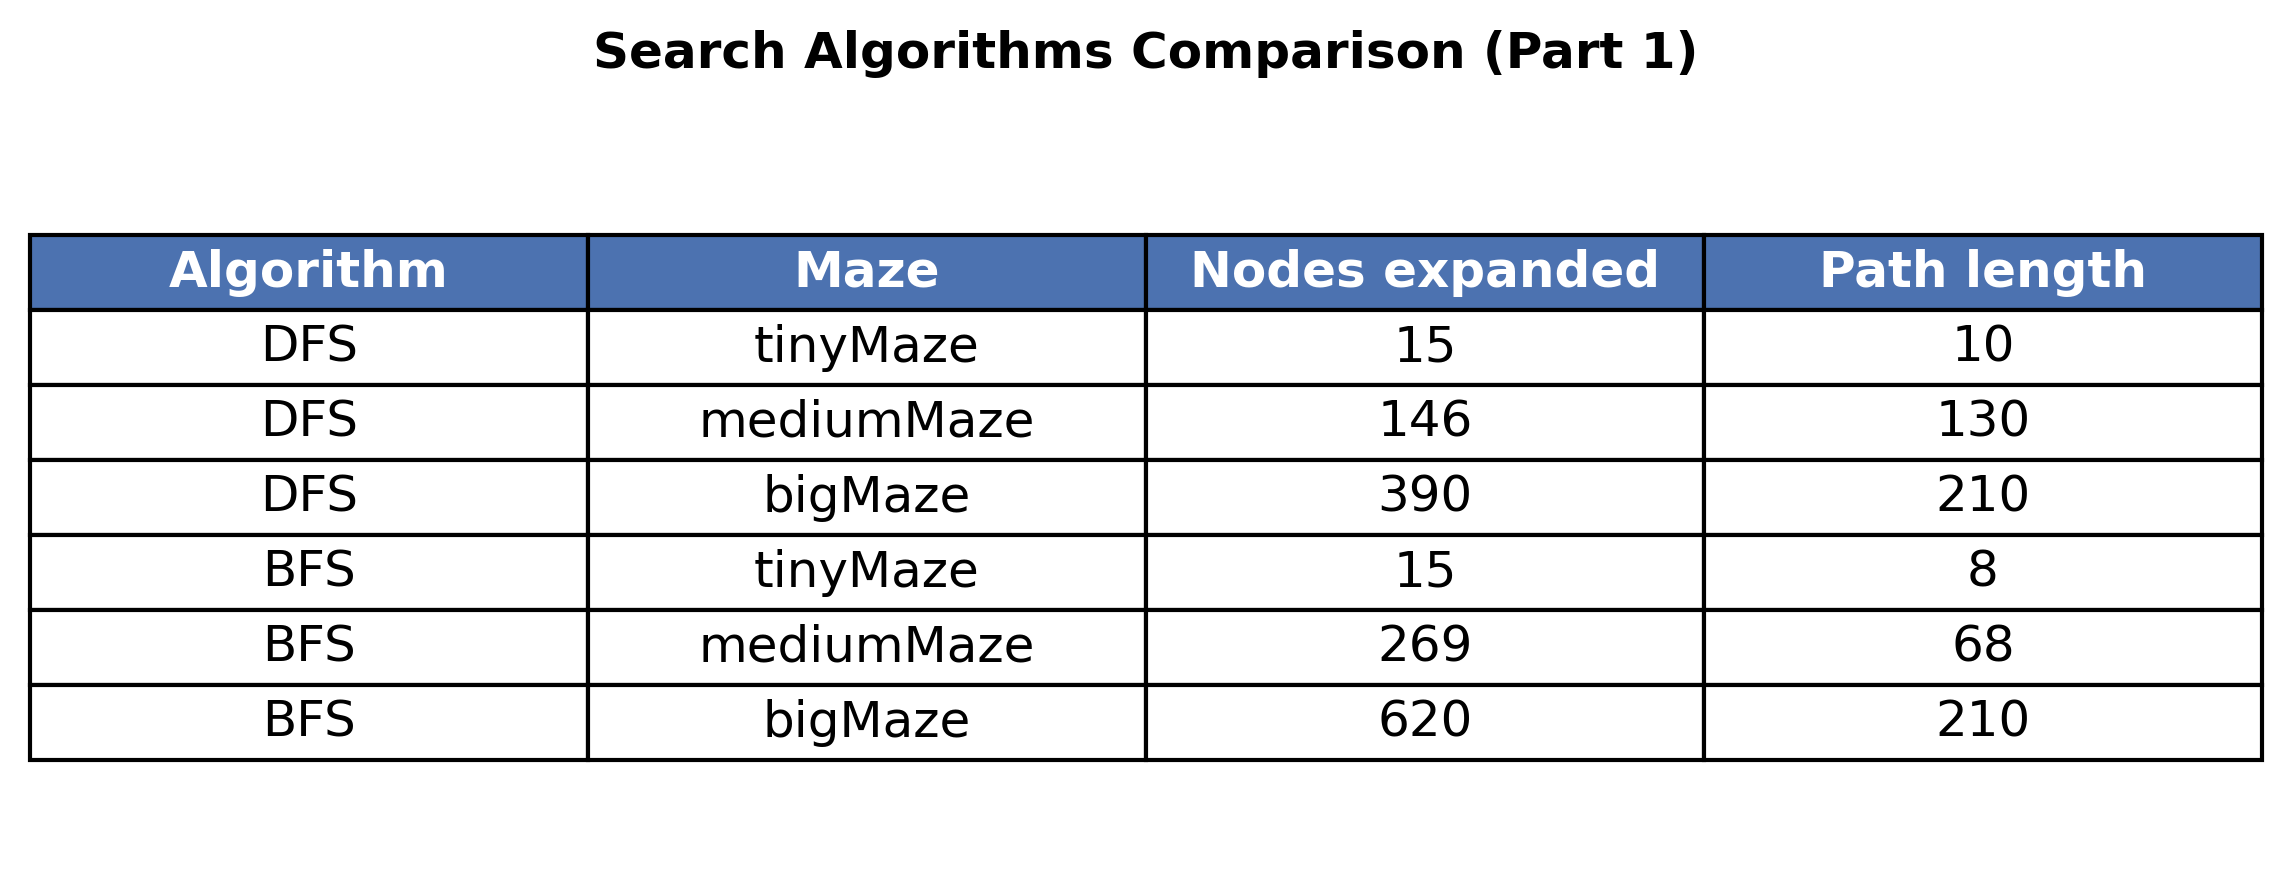

#### Preguntas

**¿DFS siempre encuentra el camino más corto? ¿Por qué o por qué no?**

No, el algoritmo DFS no garantiza encontrar el camino más corto. Como usa una estructura de pila donde el último en entrar es el primero en salir, explora un camino de tirón hasta llegar a un callejón sin salida antes de volver atrás. Por lo tanto, si encuentra la meta por un camino muy largo, dará esa solución directamente por ser la primera que ha visto, ignorando por completo que podría haber otros caminos mucho más cortos en zonas que todavía no ha revisado.

**¿BFS siempre encuentra el camino más corto? ¿Bajo qué condición está garantizado?**

Sí, el algoritmo BFS siempre encuentra el camino más corto en cuanto a cantidad de pasos. Esto se debe a que explora a los lados nivel por nivel usando una cola de tareas. Sin embargo, esto solo está garantizado si todos los pasos que damos cuestan exactamente los mismos puntos. Si moverse a ciertas casillas costara más que a otras, BFS podría encontrar un camino de pocos pasos pero con una penalización muy alta, por lo que ya no sería el mejor camino real.

# Parte 11

### Ejercicio 11.2 - Parte 1

In [47]:
!python pacman.py -l mediumMaze -p SearchAgent -a fn=ucs -t

[SearchAgent] using function ucs
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                 <%
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %
% %% % % % % %%%% %%%%%%%%% %% %%%%%
% %% % % % %             %% %%     %
% %% % % % % % %%%%  %%%    %%%%%% %
% %  % % %   %    %% %%%%%%%%      %
% %% % % %%%%%%%% %%        %% %%%%%
% %% %   %%       %%%%%%%%% %%     %
%    %%%%%% %%%%%%%      %% %%%%%% %
%%%%%%      %       %%%% %% %      %
%      %%%%%% %%%%% %    %% %% %%%%%
% %%%%%%      %       %%%%% %%     %
%        %%%%%% %%%%%%%%%%% %%  %% %
%%%%%%%%%%                  %%%%%% %
%.         %%%%%%%%%%%%%%%%        %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Score: 0

Path found with total cost of 68 in 0.0 seconds
Search nodes expanded: 269
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                > %
% %%%%%%%%%%%%%%%%%%%%%%% %%%%%%%% %
% %%   %   %      %%%%%%%   %%     %
% %% % % % % 

In [48]:
!python pacman.py -l mediumDottedMaze -p StayEastSearchAgent -t

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                 <%
% %%%%%%%%%%%%%%%%%%% %%% %%%%%%%% %
% %%   %   %      %%% %%%   %% ... %
% %% % % % % %%%% %%%%%%%%% %% %%%%%
% %% % % % % %    %%     %% %% ... %
% %% % % % % % %%%%  %%%    %%%%%% %
% %  % % %   %    %% %%%%%%%%  ... %
% %% % % %%%%%%%% %%        %% %%%%%
% %% %   %%       %%%%%%%%% %% ... %
%    %%%%%% %%%%%%%      %% %%%%%% %
%%%%%%      %       %%%% %% %  ... %
%      %%%%%% %%%%% %    %% %% %%%%%
% %%%%%%      %       %%%%% %%     %
%        %%%%%% %%%%%%%%%%% %%  %% %
%%%%%%%%%%                  %%%%%% %
%.         %%%%%%%%%%%%%%%% ...... %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Score: 0

Path found with total cost of 1 in 0.0 seconds
Search nodes expanded: 186
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                  %
% %%%%%%%%%%%%%%%%%%% %%% %%%%%%%%^%
% %%   %   %      %%% %%%   %% ... %
% %% % % % % %%%% %%%%%%%%% %% %%%%%
% %% % % % % %    %%     %% %% ... %
% %% % % % % % %%%%  %%%    

In [49]:
!python pacman.py -l mediumScaryMaze -p StayWestSearchAgent -t

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                   <%
% %%%%%%%%%%%%%%%%%%% %%%  %%%%%%%%  %
% %%   %   %      %%% %%%    %%GG    %
% %% % % % % %%%% %%%%%%%%%  %%  %%%%%
% %% % % % % %    %%GG       %%      %
% %% % % % % % %%%%%  %%%    %%%%%%  %
% %% % % %   %    %%  %%%%%%%%%      %
% %% % % %%%%%%%% %%         %%  %%%%%
% %% %   %%       %%%%%%%%%  %%      %
%    %%% %% %%%%%%%      %%  %%%%%%  %
%%%%%%      %       %    %%  %%      %
%      %%%%%% %%   %%    %%  %%  %%%%%
% %%%%%%      %       %%%%%  %%      %
%          %%%%       %%%%%  %%%%%%  %
%%%%%%%%   %                 %%%%%%  %
%.         %%%%%%%%%%%%%%%%          %
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Score: 0

Path found with total cost of 68719479864 in 0.0 seconds
Search nodes expanded: 108
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%                                  > %
% %%%%%%%%%%%%%%%%%%% %%%  %%%%%%%%  %
% %%   %   %      %%% %%%    %%      %
% %% % % % % %%%% %%%%%%%%%  %%GG%%%%%
% %% % % 

In [50]:
!python autograder.py -q q3

Starting on 5-4 at 0:47:14

Question q3
*** PASS: test_cases/q3/graph_backtrack.test
*** 	solution:		['1:A->C', '0:C->G']
*** 	expanded_states:	['A', 'B', 'C', 'D']
*** PASS: test_cases/q3/graph_bfs_vs_dfs.test
*** 	solution:		['1:A->G']
*** 	expanded_states:	['A', 'B']
*** PASS: test_cases/q3/graph_infinite.test
*** 	solution:		['0:A->B', '1:B->C', '1:C->G']
*** 	expanded_states:	['A', 'B', 'C']
*** PASS: test_cases/q3/graph_manypaths.test
*** 	solution:		['1:A->C', '0:C->D', '1:D->F', '0:F->G']
*** 	expanded_states:	['A', 'B1', 'C', 'B2', 'D', 'E1', 'F', 'E2']
*** PASS: test_cases/q3/ucs_0_graph.test
*** 	solution:		['Right', 'Down', 'Down']
*** 	expanded_states:	['A', 'B', 'D', 'C', 'G']
*** PASS: test_cases/q3/ucs_1_problemC.test
*** 	pacman layout:		mediumMaze
*** 	solution length: 68
*** 	nodes expanded:		269
*** PASS: test_cases/q3/ucs_2_problemE.test
*** 	pacman layout:		mediumMaze
*** 	solution length: 74
*** 	nodes expanded:		260
*** PASS: test_cases/q3/ucs_3_problemW.test
**

### Ejercicio 11.2 - Parte 2

In [51]:
!python pacman.py -l bigMaze -p SearchAgent -a fn=astar,heuristic=manhattanHeuristic -t

[SearchAgent] using function astar and heuristic manhattanHeuristic
[SearchAgent] using problem type PositionSearchProblem
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%       % % %           %   %     % %
% %%%%%%% % %%% % %%% %%% %%%%%%% % %
%       %       % %     %     % %   %
%%%%% %%%%% %%% % % % %%% %%%%% % %%%
%   % % % %   % % % %   % %   % %   %
% %%% % % % %%% %%%%% %%% % %%% %%% %
%       %     %   %   %     % % %   %
%%% %%%%%%%%% %%%%%%% %%% %%% % % % %
%             %       % %   %     % %
% % %%%%% % %%% % % %%% % %%% %%% % %
% % %     % % % % %     %   % % % % %
% % % %%%%%%% % %%%%%%%%% %%% % %%% %
% % % %     %   %     %     %   %   %
%%% %%% % %%%%% %%%%% %%% %%% %%%%% %
%     % % %     % %     % %   % % % %
% % % % % %%% %%% %%% %%% % % % % % %
% % % % %                 % % %     %
%%% %%%%%%% % % %%%%% %%% % %%% %%%%%
%       % % % %     %   %     % %   %
%%%%% % % %%%%%%%%% %%%%%%%%%%% % %%%
%   % %           % %     %   % %   %
% %%% %%%%% %%%%%%%%% %%%%% % % %%% %
% %

In [52]:
!python autograder.py -q q4

Starting on 5-4 at 0:47:35

Question q4
*** PASS: test_cases/q4/astar_0.test
*** 	solution:		['Right', 'Down', 'Down']
*** 	expanded_states:	['A', 'B', 'D', 'C', 'G']
*** PASS: test_cases/q4/astar_1_graph_heuristic.test
*** 	solution:		['0', '0', '2']
*** 	expanded_states:	['S', 'A', 'D', 'C']
*** PASS: test_cases/q4/astar_2_manhattan.test
*** 	pacman layout:		mediumMaze
*** 	solution length: 68
*** 	nodes expanded:		221
*** PASS: test_cases/q4/astar_3_goalAtDequeue.test
*** 	solution:		['1:A->B', '0:B->C', '0:C->G']
*** 	expanded_states:	['A', 'B', 'C']
*** PASS: test_cases/q4/astar_expand_1.test
*** 	solution:		['0', '0', '0']
*** 	expanded_states:	['Q', 'B', 'A', 'B']
*** PASS: test_cases/q4/astar_expand_2.test
*** 	solution:		['0:A->B', '0:B->C', '0:C->D', '0:D->E', '0:E->F', '0:F->G']
*** 	expanded_states:	['A', 'C', 'D', 'F', 'E', 'F', 'B', 'C', 'D', 'E', 'F']
*** PASS: test_cases/q4/graph_backtrack.test
*** 	solution:		['1:A->C', '0:C->G']
*** 	expanded_states:	['A', 'B', 'C', '

### Ejercicio 11.2 - Parte 3

#### Reportaje
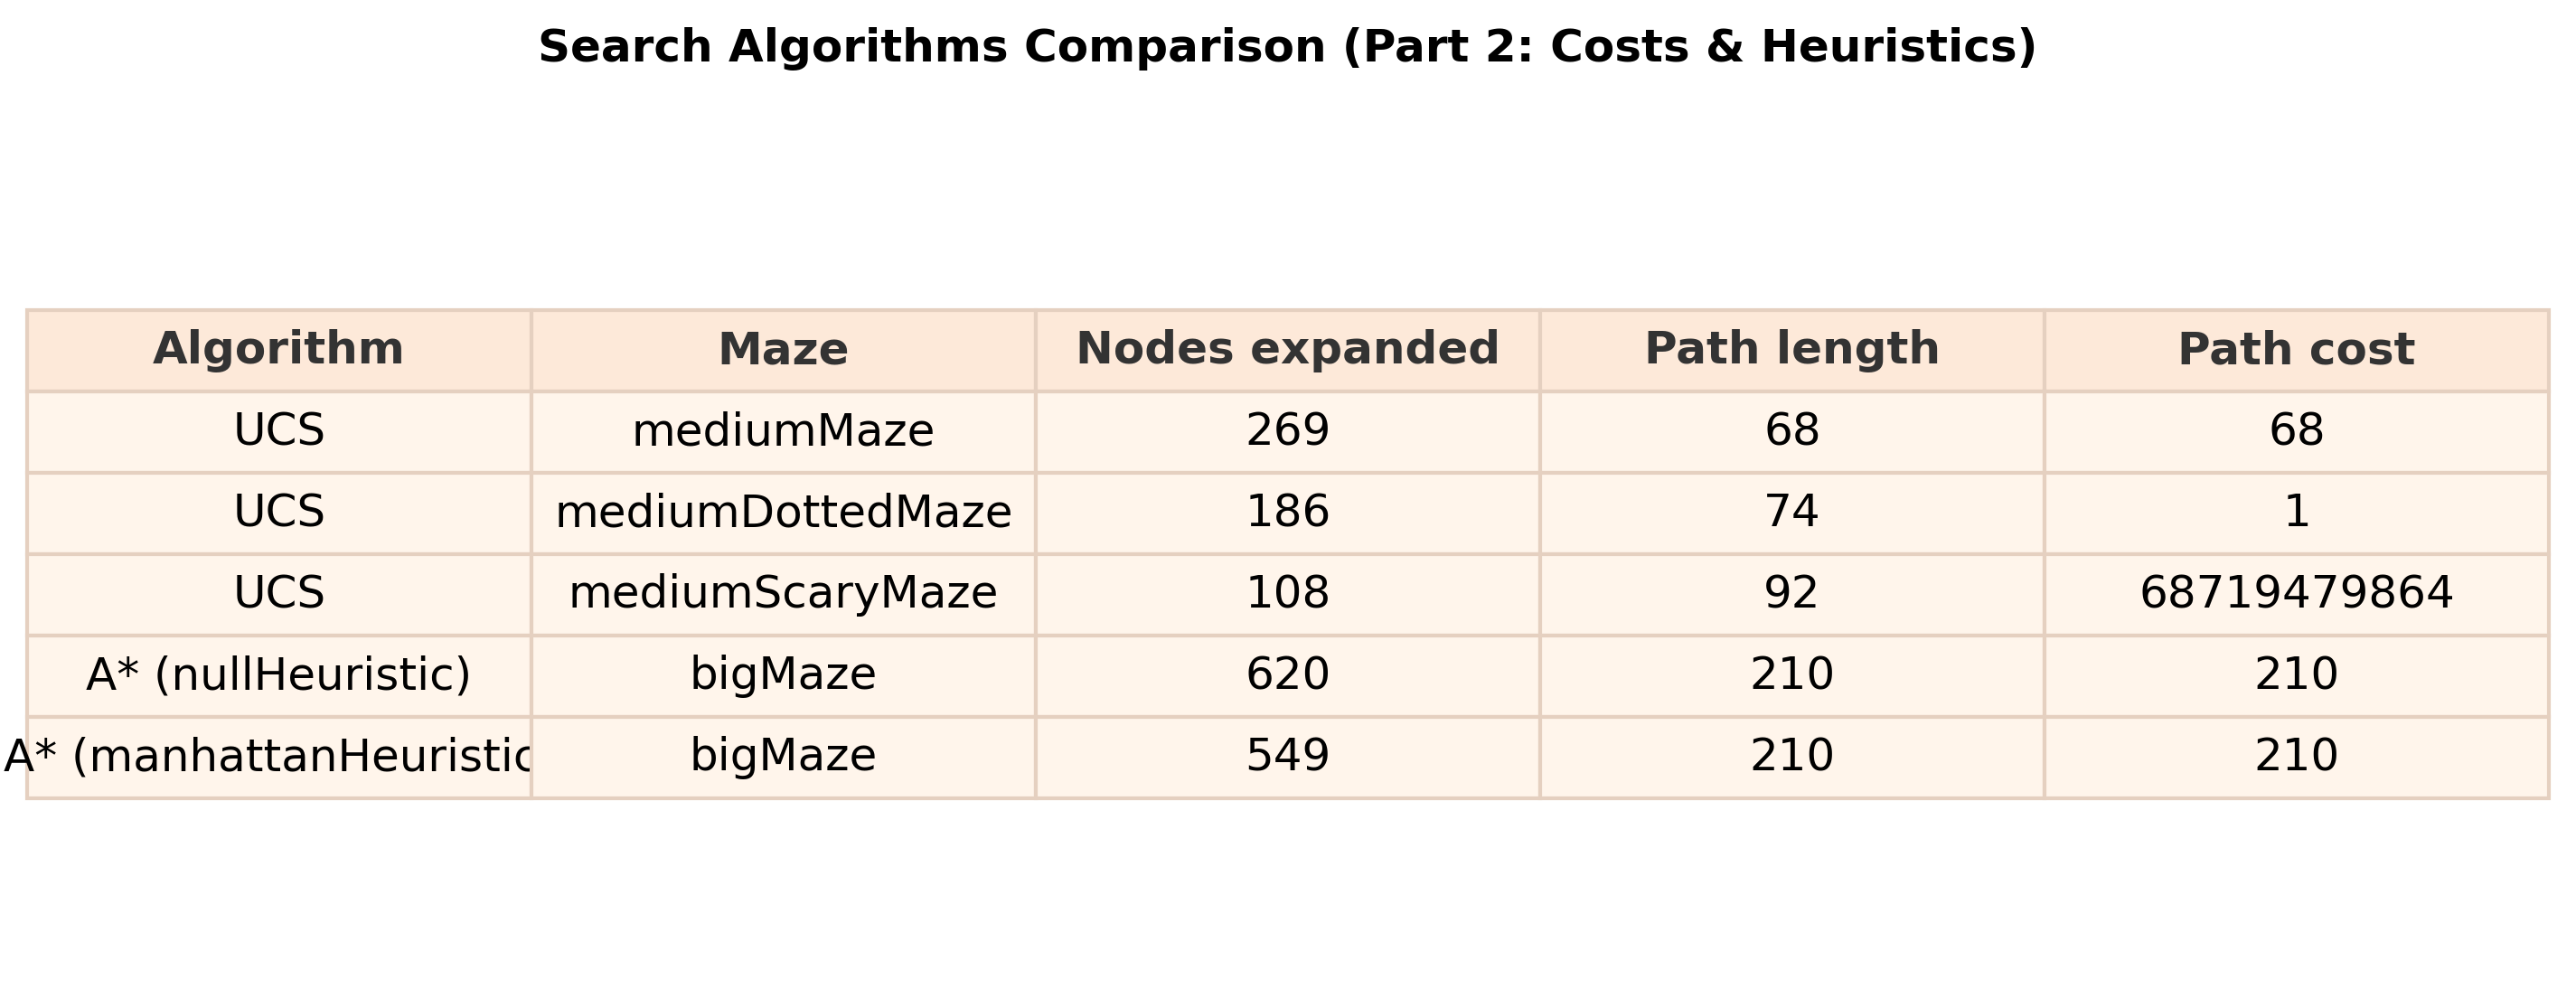

#### Preguntas

**En mediumMaze, ¿UCS encuentra el mismo camino que BFS? ¿Por qué o por qué no?**

Sí, ambos encuentran rutas de la misma longitud y coste en ese mapa. Esto ocurre porque es un laberinto normal donde cada paso cuesta un punto sin importar la dirección. Como el algoritmo UCS busca el camino más barato contando los puntos acumulados, al valer todos los pasos lo mismo acaba comportándose exactamente igual que BFS y expandiéndose por niveles de la misma manera.

**En bigMaze, ¿cuántos nodos expande A\* con manhattanHeuristic comparado con nullHeuristic? ¿Qué te dice esto sobre el valor de una buena heurística?**

Según nuestros datos, A* con la heurística nula miró 620 casillas, mientras que al usar la heurística de Manhattan bajó a 549 casillas encontrando la misma ruta ideal. Esto demuestra que una buena pista inicial le da sentido de la orientación al programa. Al saber más o menos cuánto falta para llegar a la meta, el algoritmo puede ignorar los caminos que claramente lo alejan del objetivo ahorrando tiempo de cálculo sin equivocarse en la ruta final.

**¿Por qué visited debe marcarse en el *pop* en UCS y A\*, pero marcarse en el *push* es seguro en BFS?**

En BFS, al explorar por niveles exactos, la primera vez que descubres una casilla y la guardas en memoria sabes seguro que has llegado a ella dando el menor número de pasos. Sin embargo en UCS y A*, la primera vez que ves una casilla no significa que sea la forma más barata de llegar a ella. Si esperamos a marcarla como visitada justo al momento de sacarla de la cola para procesarla, nos aseguramos de que el algoritmo ya ha ordenado todas sus opciones y ha elegido de verdad el camino que menos puntos cuesta.

# Parte 12

### Ejercicio 12.2 - Parte 1

#### Reportaje
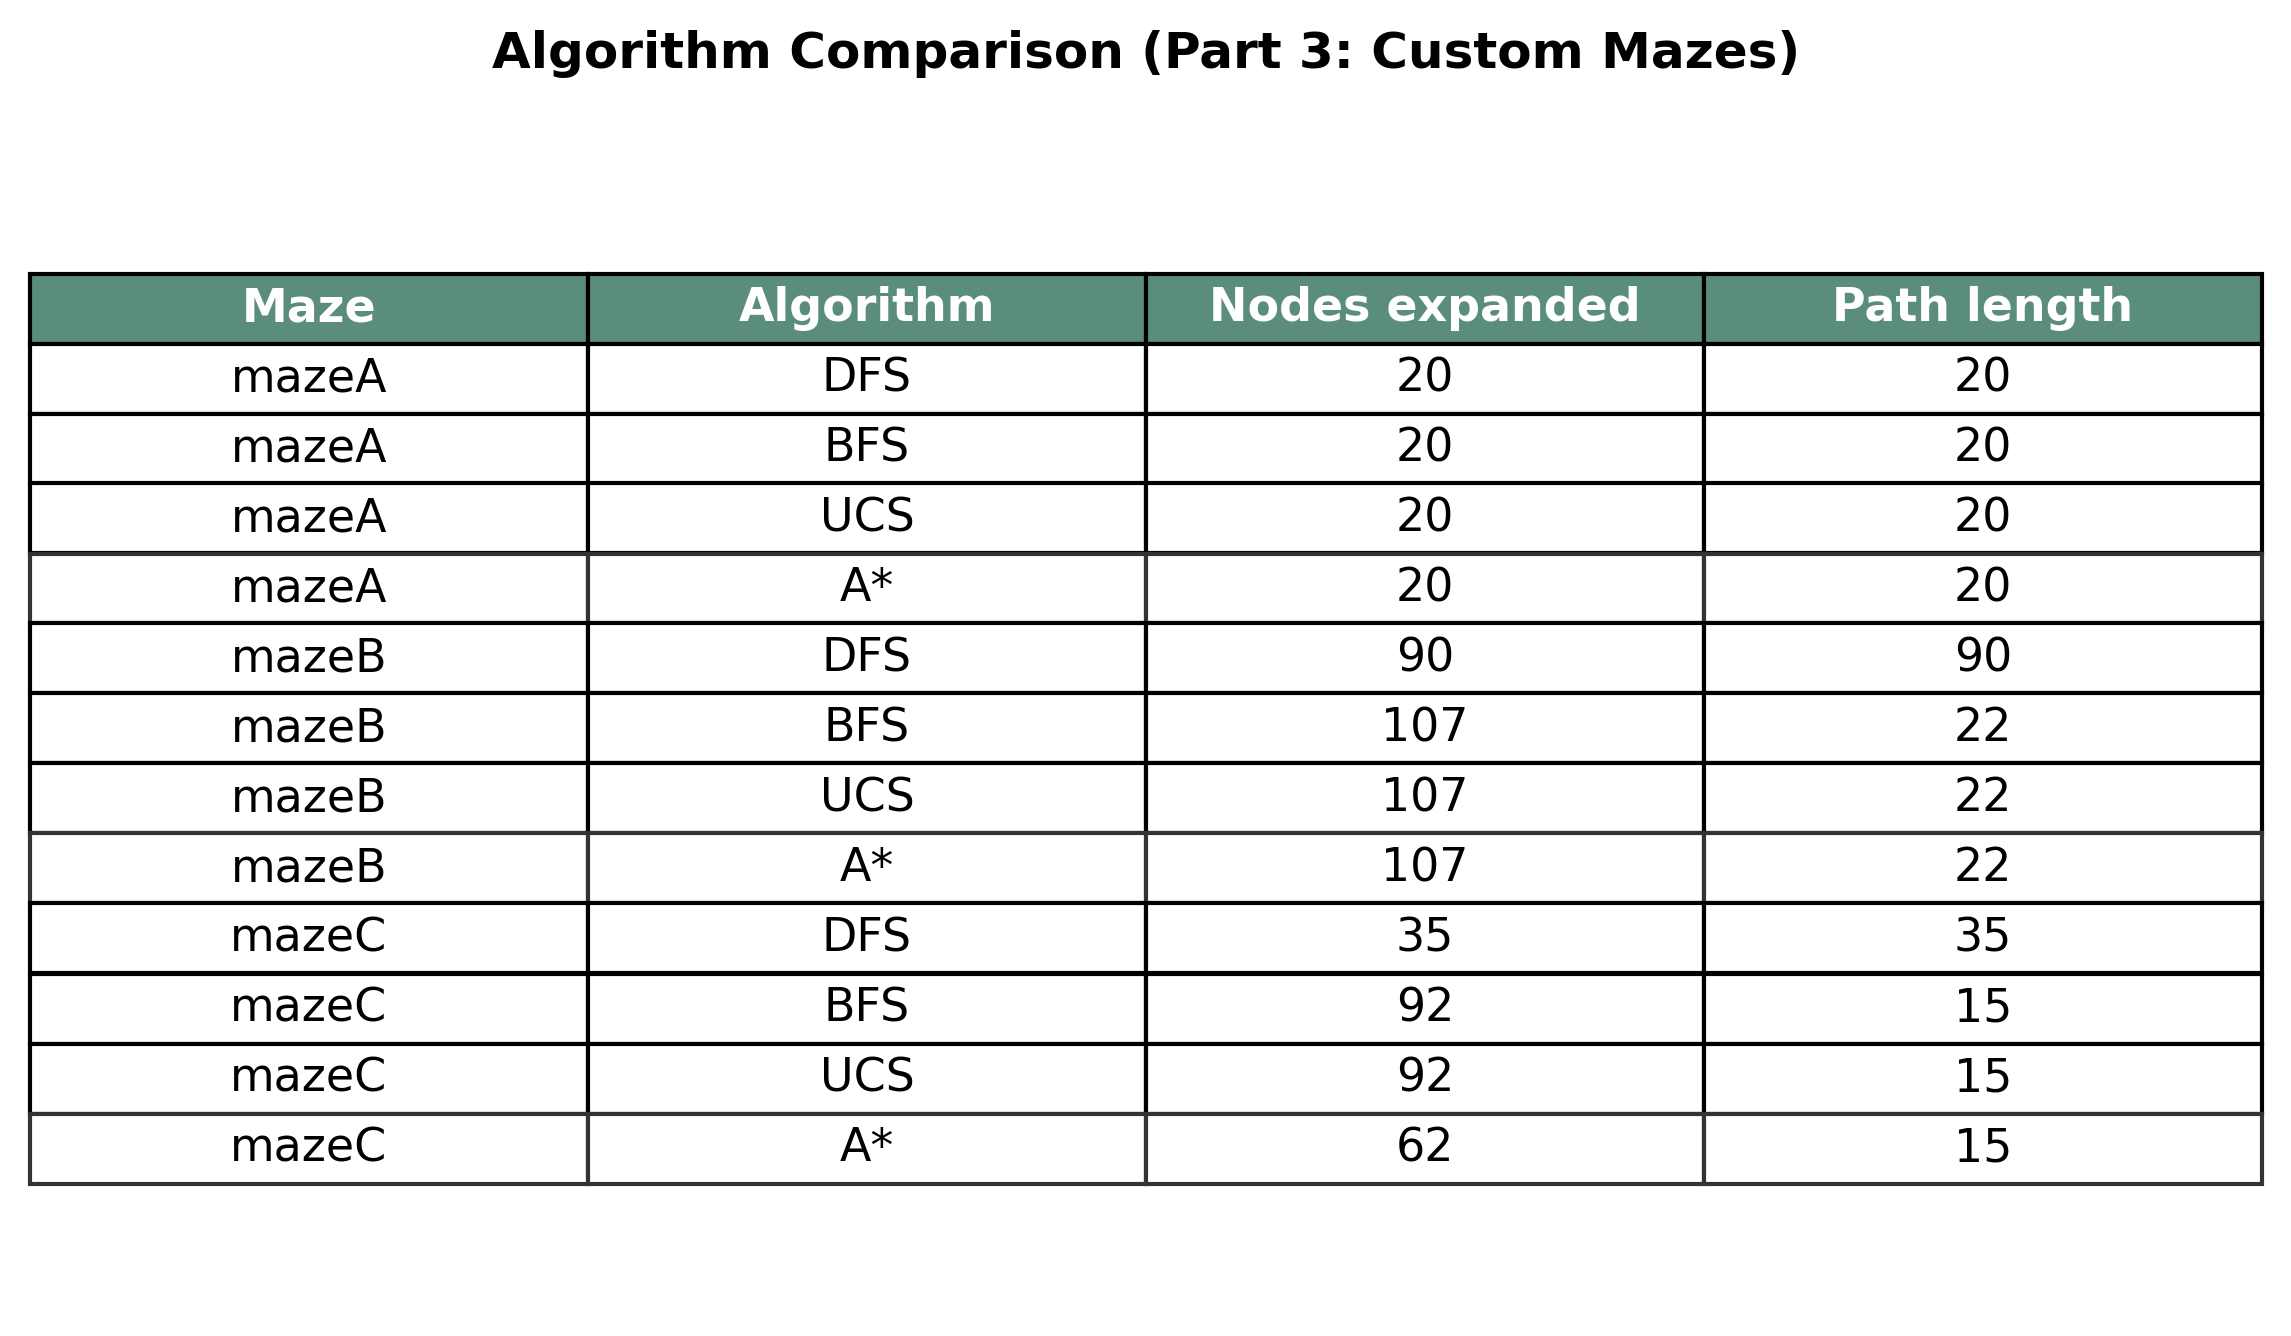

### Ejercicio 12.2 - Parte 2

#### Escenario Customizado
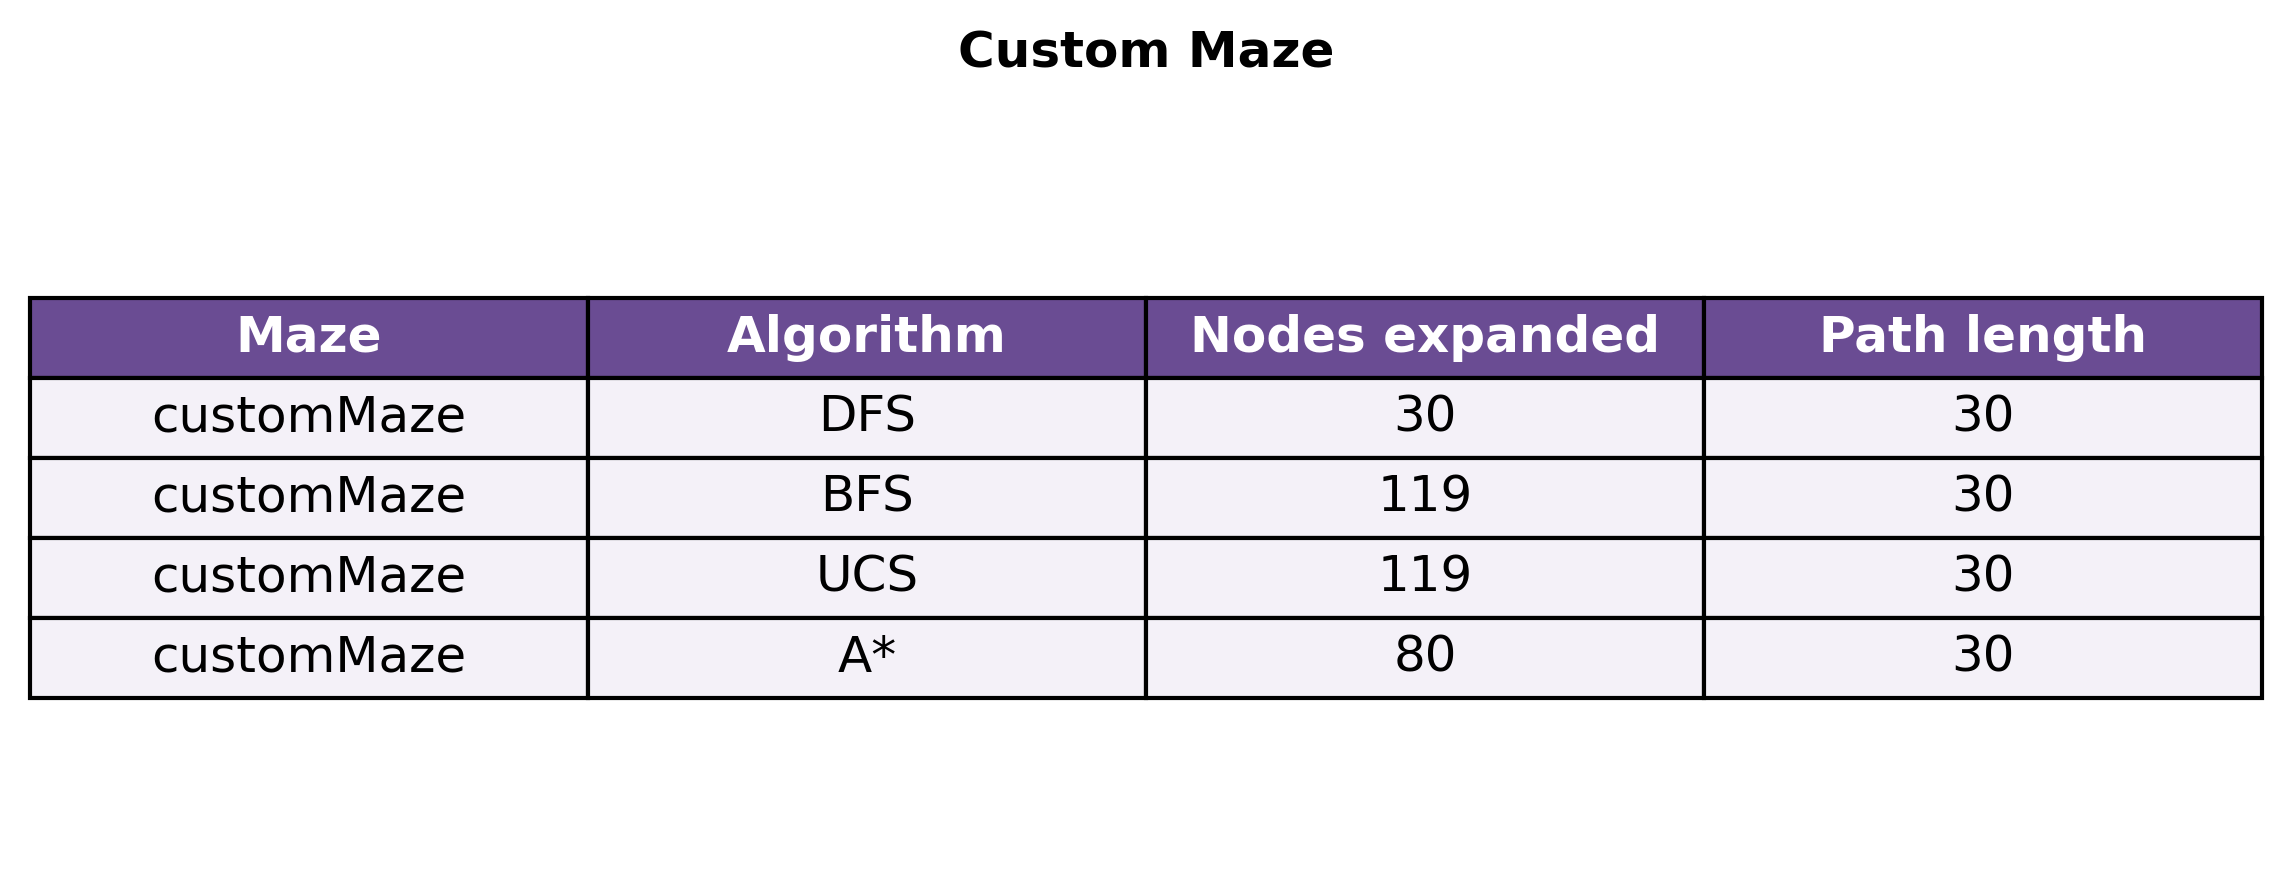

##### Laberinto Customizado
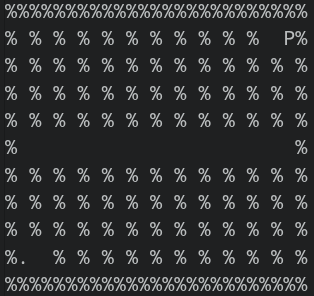

**Explica en un párrafo corto por qué esperas que tu laberinto favorezca a un algoritmo y si los resultados confirmaron tu expectativa.**

Diseñé el laberinto con un pasillo central directo hacia la meta, pero rodeado de caminos largos hacia arriba y hacia abajo sin salida. Mi idea era que los algoritmos que se expanden a los lados a la vez explorarían todos esos pasillos inútiles y perderían muchísimo tiempo. Por el contrario, esperaba que A* usara su conocimiento sobre la distancia a la meta para darse cuenta de que entrar en esos huecos lo alejaba del objetivo para ir directo por el pasillo del medio. Los resultados confirmaron esto perfectamente, ya que A* revisó muchísimas menos casillas que el resto de los modelos.

### Ejercicio 12.2 - Parte 3

**A través de todos los laberintos probados, ¿qué algoritmo expande consistentemente la menor cantidad de nodos? ¿Cambia la respuesta dependiendo de la estructura del laberinto?**

Por lo general, A* es el modelo que mira la menor cantidad de casillas casi siempre porque tiene esa intuición directa de hacia dónde debe ir. Sin embargo la respuesta puede cambiar dependiendo de la forma del mapa. Si hay paredes anchas con forma de vaso que te obligan a alejarte de la meta temporalmente para poder avanzar, A* perderá mucho tiempo chocando contra esa pared intentando ir recto antes de rendirse y dar un rodeo largo. En esos casos tan concretos, un modelo que mire todo por igual podría encontrar el atajo más rápido.

**BFS y UCS ambos garantizan el camino óptimo. ¿Encontraron caminos de la misma longitud en mediumMaze? Explica por qué o por qué no.**

Sí, los dos encontraron una ruta exacta de 68 pasos. Esto pasa porque buscar el mejor camino significa cosas distintas para cada uno de ellos. BFS busca dar el menor número de pasos físicos y UCS busca gastar la menor cantidad de puntos del juego. Como en ese mapa todos los pasos cuestan un solo punto y no hay zonas difíciles que cuesten más esfuerzo cruzar, dar menos pasos físicos es exactamente lo mismo que gastar menos puntos totales. Por eso ambos coinciden en el resultado final.

**Describe un escenario (una forma específica de laberinto o estructura de costes) donde elegirías cada uno de los cuatro algoritmos. Justifica tu elección.**

DFS lo usaría en laberintos gigantescos donde la memoria de mi ordenador se pueda quedar corta rápido, siempre y cuando me valga encontrar cualquier salida y no necesite que sea el camino más corto. BFS lo elegiría para laberintos normales en forma de cuadrícula donde todos los movimientos valen lo mismo, ya que encuentra rápido la salida sin tener que hacer sumas extra. UCS sería mi opción ideal en mapas donde hay diferentes tipos de suelo con costes distintos como zonas de barro o veneno que penalizan tus puntos, pero donde no le puedo dar pistas al programa sobre dónde está la meta final. Finalmente, A* lo usaría siempre como primera opción para cualquier mapa de un juego donde haya zonas de coste variado y además sepa las coordenadas exactas de la meta, para no perder el tiempo buscando en direcciones incorrectas.